> Wer die Wahl hat, hat die Qual

___
In dieser Kurseinheit werden wir uns mit der Datenmodellierung für dokument-orientierte Datenbanksysteme beschäftigen.

**_Bitte beachten:_**

- In Raw-Zellen erwarten wir Antworten im Freitext-Format. In Code-Zellen soll Code eingefügt werden (bei Bedarf mit Kommentaren).
- Fragestellungen sind teilweise bewusst etwas offener formuliert, weil Sie auch im Arbeitsleben nur selten mit ganz spezifischen Anweisungen rechnen können. Es gibt häufig mehrere mögliche Lösungen, dies wird in der Korrektur berücksichtigt.
 
 
Zum Importieren der Daten empfehlen wir aufgrund seiner Einfachheit <a href="https://www.mongodb.com/docs/database-tools/mongoimport/">mongoimport</a>, für Datenabfragen wird die Verwendung von <a href="https://pymongo.readthedocs.io/en/stable/">PyMongo</a> vorgeschlagen.

Falls Sie sich für den Einsatz anderer Tools entscheiden, denken Sie daran, die entsprechenden Installationen vorzunehmen.

Die Verwendung externer Quellen und das Einfügen von Anmerkungen am Ende des Protokolls ist weiterhin erlaubt! :)

___

Refill-Deutschland und Mundraub sind Plattformen, die die Standorte von Früchten, Pflanzen und Zapfstellen (Wasser) in Deutschland erfassen. Beide Datensätze stammen aus <a href="https://www.govdata.de/">GovData</a> und beinhalten geographische Punkte, an denen es freien Zugang zu Wasser und Lebensmittel gibt. Angesichts der positiven Resonanz, die die Projekte Mundraub- und die Refillstationen- in den sozialen Netzwerken erfahren haben, ist es unser Ziel, beide strategisch zu fördern. Dazu sollen die Informationen beider Projekte auf einer zentralen Plattform zusammengeführt werden.



In [ ]:
# Imports
from pymongo import MongoClient
from pprint import pprint

Da wir im weiteren Verlauf Zugriff auf die Daten benötigen, stellen wir zunächst die entsprechenden Variablen ein.

In [ ]:
import os

# Absolute path :: to the folder cotaining the git repo
host_repo_path = "/CHANGE/ME/"
# Relative path :: to the folder containing following files (INSIDE OF THE WORKSPACE FOLDER!)
# refill_KE.csv
# mundraub_KE.csv
workspace_data_path = "CHANGE/ME"
os.environ['HOST_DATA_PATH'] = os.path.join(host_repo_path, "workspace", workspace_data_path)
os.environ['DATA_PATH'] = os.path.join("/home/pyspark-client/workspace", workspace_data_path)
# uncomment to verify the content of the DATA_PATH
#!ls ${DATA_PATH}

# Schema Design
Ein durchdachter Schemaentwurf ist entscheidend, um die Performance zu optimieren, die Komplexität zu reduzieren und die Skalierbarkeit des Systems sicherzustellen. Im Gegensatz zu relationalen Datenbanken folgt das Schema-Design in MongoDB keinem formalen Prozess oder festen Regeln. Stattdessen orientiert es sich stark an den Anforderungen der jeweiligen Anwendung. Dadurch können identische Informationen in unterschiedlichen Anwendungen sehr verschieden modelliert sein können.

Beim Entwurf eines MongoDB-Schemas stehen für jedes Datenelement grundsätzlich zwei Modellierungsoptionen zur Verfügung: Die Daten können entweder eingebettet werden oder über Referenzen auf andere Dokumente verweisen. Darüber hinaus gibt es verschiedene <a href="https://www.mongodb.com/blog/post/building-with-patterns-a-summary">Design Patterns</a>.

Es gibt zwar keine strengen Regeln, aber es gibt hilfreiche Richtlinien aus der Praxis. Wenn Sie mehr erfahren möchten, nutzen Sie den Schieberegler unten.

* Einbettung sollte grundsätzlich bevorzugt werden, sofern nicht ein triftiger Grund dagegen spricht (Daten, die gemeinsam abgefragt werden, sollen auch gemeinsam gespeichert werden.)
* Muss ein Objekt eigenständig zugänglich sein, gilt dies als legitimer Grund, es nicht einzubetten.
* Joins bzw. `$lookup`-Operationen sollte man vermeiden, aber nicht fürchten: Sie können in bestimmten Fällen ein besseres Schema ermöglichen.
* Arrays sollten nicht unbegrenzt wachsen. Bei mehr als einigen hundert Dokumenten auf der Many-Seite ist Einbettung nicht zu empfehlen; bei mehreren tausend sollte auch auf ObjectID-Referenzen in Arrays verzichtet werden. Eine hohe Kardinalität oder stetig wachsende Dokumente sind triftige Gründe, auf die Einbettung zu verzichten.
* In MongoDB hängt die Modellierung stets von den konkreten Datenzugriffsmustern der Anwendung ab. Die Daten sollten so strukturiert werden, dass sie zu den Abfragen Ihrer Anwendung passen.

Das geplante System soll die folgenden Abfragen unterstützen:

**Read-Abfragen:**

- **Q1**. Gesamtanzahl aller vorhandenen Standorte anzeigen. _SEHR HÄUFIG_
    - _Auszugebende Attribute_: *count_locations*

- **Q2**. Gesamtanzahl aller Mundraub-Plätze. _SEHR HÄUFIG_
    - _Auszugebende Attribute_: *total_mundraub*

- **Q3**. Gesamtanzahl aller Refill-Stationen. _SEHR HÄUFIG_
    - _Auszugebende Attribute_: *total_refill*

- **Q4**. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln. _HÄUFIG_
    - _Gegebene Attribute_: *Location.geom.longitude*, *Location.geom.latitude*, *maxDistance*
    - _Auszugebende Attribute_: *Station.fid*, Distance, *Refill.station_name*, *Mundraub.kind*, *Station.typ*
  
- **Q5**. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen. _HÄUFIG_ 
    - _Gegebene Attribute_: *Station.fid*
    - _Auszugebende Attribute_: *Station.fid*, *Station.rating*, *Refill.station_name*, *Refill.opening_hours*, *Refill.description*, *Location.city*, *Location.geom*, *Location.id*, *Location.plz*, *Location.street*, *Feedback.content*, *Feedback.created_at*, *Feedback.id*, *Feedback.rating*
        
**Write-Abfragen:**

- **Q6**. Einen neues Feedback zu einer Station hinzufügen. _NORMALERWEISE_
    - _Gegebene Attribute_: *Station.fid*, *Feedback.rating*, *Feedback.content*

- **Q7**. Einen neuen Standort mit einer neuen Station anlegen. _SELTEN_
    - _Gegebene Attribute_: *Location.geom.longitude*, *Location.geom.latitude*, *Location.street*, *Location.plz*, *Location.city*, *Station.fid*, *Station.station_name*, *Station.opening_hours*, *Station.description*
    
- **Q8**. Die Öffnungszeiten einer Station aktualisieren. _SELTEN_
    - _Gegebene Attribute_: *refill.fid*, *refill.opening_hours*
    
- **Q9**. Eine bestehende Station löschen. _SEHR SELTEN_
    - _Gegebene Attribute_: *mundraub.fid*

Ein Arbeitskollege hat die Modellierung in MongoDB übernommen. Ihm fehlt es jedoch an Erfahrung. Deshalb hat er sich an Sie gewandt, um sich beraten zu lassen. Das folgende Bild zeigt seine drei Vorschläge.
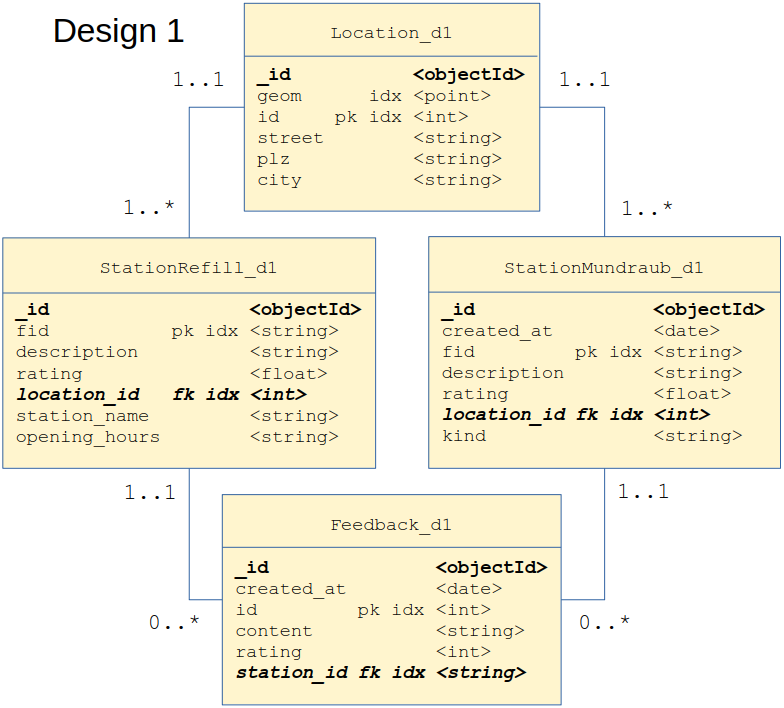

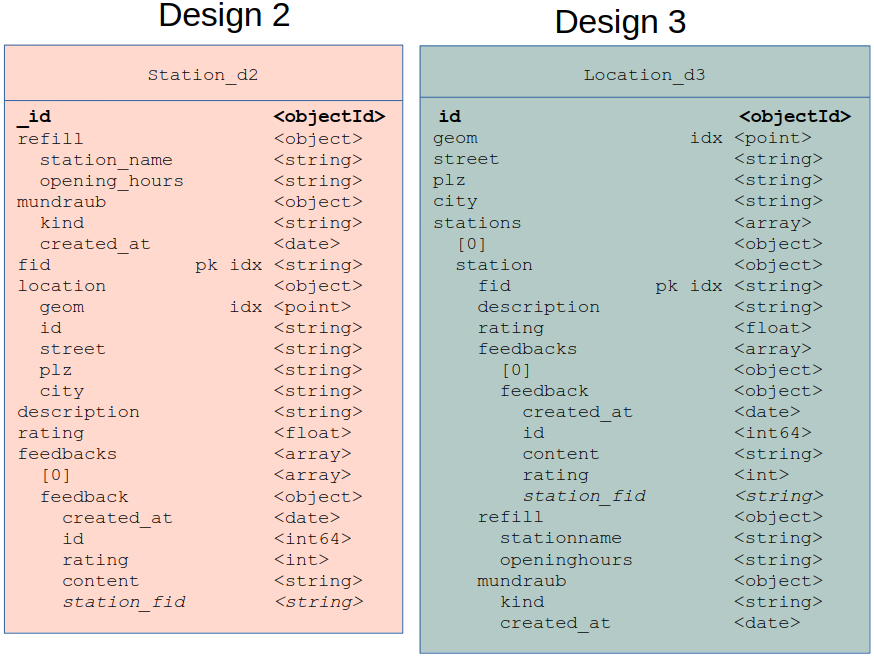

## Spaghetti-Teller – verschachtelt, verknüpft und ungenießbar
Um einen ersten übersichtlichen Vergleich der drei Entwürfe zu ermöglichen, füllen Sie bitte die folgende Tabelle aus. Verwenden Sie dazu die folgenden Tags.

- _JOIN_: Aufgrund der Referenzierung sind eine oder mehrere Join-Operationen oder mehrere Abfragen erforderlich.
- _SIZE_: Eine "unendliche" Einbettung von Elementen könnte die 16-MB-Grenze beeinträchtigen.
- _FILTERUNG_: Um Informationen zu gewinnen, müssen eine "große" Mengen an Daten mit "komplexen" Operationen verarbeitet werden, z.B group.

Query  | **Design 1** | **Design 2** | **Design 3**
:-----:|:------------:|:------------:|:--------:
**Q1** |              |              |
**Q2** |              |              |
**Q3** |              |              |
**Q4** |              |              |
**Q5** |              |              |
**Q6** |              |              |
**Q7** |              |              |
**Q8** |              |              |
**Q9** |              |              |

## Dicker Doc, langsamer Join
Bitte nennen Sie kurz die aus Ihrer Sicht jeweils größten Nachteile der einzelnen Designs.

Welches Design finden Sie am besten? Bitte begründen Sie Ihre Wahl kurz.

# Daten import
Im Folgenden beschäftigen wir uns mit dem Import der Daten. Dazu verwenden wir das zuvor ausgewählte Design.

Führen Sie die folgende Zelle aus, um den Docker-Container mit einer MongoDB-Datenbank zu starten. Dieser befindet sich im selben Docker-Netzwerk wie die anderen Container.

In [ ]:
%%bash

sudo docker run -d --rm \
--name mongo_container_1 \
--hostname mongo_container_1 \
-v "${HOST_DATA_PATH}:/mnt/workspace:ro" \
-e BROWSERSLIST_IGNORE_OLD_DATA=1 \
--network dbis-hadoop-cluster-network \
-p 127.0.0.1:27017:27017 \
mongo:8.0.0-rc11-jammy

Vergewissern Sie sich wieder, dass der Container läuft:

In [ ]:
%%bash

sudo docker ps --filter "name=mongo_container_1" --format "table {{.Names}}\t{{.Status}}"

Führen Sie die folgende Zelle aus, wenn Sie überprüfen möchten, ob die JSON-Dateien im Container vorhanden sind. Falls dies nicht der Fall ist, überprüfen Sie bitte den Pfad, den wir zu Beginn dieses Arbeitsdokuments definiert haben.

In [ ]:
%%bash
sudo docker exec mongo_container_1 ls /mnt/workspace

## Lieber ein langsamer Import als ein schneller Absturz
Verwenden Sie <a href="https://www.mongodb.com/docs/database-tools/mongoimport/">mongoimport</a>, um die Dateien zu importieren. Abweichend zu mongoimport kann hier auch <a href="https://pymongo.readthedocs.io/en/stable/">PyMongo</a> verwendet werden. Diese ist ebenfalls bereits installiert.

In [ ]:
##  Insert JSON-file with mongoimport
!printf "\n## Import to TODO ...\n"
!sudo docker exec -i mongo_container_1 mongoimport \
--drop \
--db=refill_mundraub \
--collection=# TODO \
--jsonArray \
# TODO file

**Datenbank Verbindung:**
Stellen Sie die Verbindung zur Datenbank `refill_mundraub` her. Verwenden Sie PyMongo und definieren Sie Variablen, die Ihnen die Nutzung der benötigten Collections ermöglichen.

In [ ]:
# conect to server
mongo_client = MongoClient('mongodb://mongo_container_1:27017/')
# TODO

In [ ]:
## Collections Design X
# TODO

**Erstelle Indexe:** Erstellen Sie Indizes, um die unterschiedlichen Abfragen zu optimieren, bzw. zu ermöglichen (<a href="https://www.mongodb.com/docs/manual/core/indexes/index-types/index-geospatial/">Geospatial Indexes</a>).

In [ ]:
## Indizes Design X
# TODO

## Wer falsch fragt, bekommt auch falsche Antworten
Bitte erstellen und führen Sie die folgenden Abfragen aus.

*Hinweis: Zur besseren Übersicht werden die erwarteten Ergebnisse in Tabellenform und nicht im JSON-Format angegeben. Um die Lesbarkeit zu verbessern, wurden einige Tabellen vertikal geteilt und getrennt dargestellt.*

**Abfragen:**
Zu jeder Abfrage sind außerdem die anzuzeigenden Attribute angegeben.

- **Q1. Gesamtanzahl aller vorhandenen Standorte anzeigen.**
    - Auszugebende Attribute: *count_locations*
    - Erwartete Ausgaben:

| count_locations |
|:---------------:|
| 1476            |

- **Q2. Gesamtanzahl aller Mundraub-Plätze.**
    - Auszugebende Attribute: *total_mundraub*
    - Erwartete Ausgaben:

| total_mundraub |
|:--------------:|
| 1365           |

- **Q3. Gesamtanzahl aller Refill-Stationen.**
    - Auszugebende Attribute: *total_refill*
    - Erwartete Ausgaben:

| total_refill |
|:------------:|
| 181          |

- **Q4. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.** Geben Sie bitte alle Stationen im Umkreis von 2,5 km um die Koordinaten 8,62 (Längengrad) und 49,72 (Breitengrad) an.
    - Gegebene Attribute: 
        * _Location.geom.longitude_ = 8.62
        * _Location.geom.latitude_ = 49.72
        * _maxDistance_ = 2.5 km
    - Auszugebende Attribute: *Station.fid*, Distance, *Refill.station_name*, *Mundraub.kind*, *Station.typ*
    - Erwartete Ausgaben:

| Station.fid                  | Distance | Station station_name/kind             |
|:----------------------------:|---------:|:-------------------------------------:|
| MRN_mundraub_4326_Point.1362 |  845.347 | Brombeere                             |
| MRN_mundraub_4326_Point.1363 |  864.717 | Pflaume                               |
| MRN_mundraub_4326_Point.1364 |  904.313 | Johannisbeere                         |
| MRN_mundraub_4326_Point.1359 |  911.757 | Holunder                              |
| MRN_mundraub_4326_Point.1365 |  933.993 | Mirabelle                             |
| MRN_mundraub_4326_Point.1360 |  981.175 | Walnuss                               |
| MRN_Refill_4326_Point.148    | 1959.330 | Hörgeräte Henning                     |
| MRN_Refill_4326_Point.157    | 1994.378 | physio³                               |
| MRN_Refill_4326_Point.158    | 2293.275 | Tupperware Bezirkshandlung Bergstraße |
| MRN_mundraub_4326_Point.1353 | 2414.048 | Bärlauch                              |
| MRN_mundraub_4326_Point.1354 | 2462.863 | Bärlauch                              |

| Station.fid                  | Station.typ | 
|:----------------------------:|------------:|
| MRN_mundraub_4326_Point.1362 | mundraub    |
| MRN_mundraub_4326_Point.1363 | mundraub    |
| MRN_mundraub_4326_Point.1364 | mundraub    |
| MRN_mundraub_4326_Point.1359 | mundraub    |
| MRN_mundraub_4326_Point.1365 | mundraub    |
| MRN_mundraub_4326_Point.1360 | mundraub    |
| MRN_Refill_4326_Point.148    | refill      |
| MRN_Refill_4326_Point.157    | refill      |
| MRN_Refill_4326_Point.158    | refill      |
| MRN_mundraub_4326_Point.1353 | mundraub    |
| MRN_mundraub_4326_Point.1354 | mundraub    |
  
- **Q5. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.** Geben Sie die Station "MRN_Refill_4326_Point.39" und Ihre letzten fünf Feedback-Einträge aus.
    - Gegebene Attribute: 
        * _Station.fid_ = MRN_Refill_4326_Point.39
    - Auszugebende Attribute: *Station.fid*, *Station.rating*, *Refill.station_name*, *Refill.opening_hours*, *Refill.description*, *Location.city*, *Location.geom*, *Location.id*, *Location.plz*, *Location.street*, *Feedback.content*, *Feedback.created_at*, *Feedback.id*, *Feedback.rating*
    - Erwartete Ausgaben:
  
| Station.fid              | Station.rating    | Refill.station_name         |
|:------------------------:|:-----------------:|:---------------------------:|
| MRN_Refill_4326_Point.39 | 3.693877551020408 | Arte e Gusto                |

| Refill.opening_hours         | Refill.description          |
|:----------------------------:|:---------------------------:|
|Mo-Fr 9:00-19:00 Sa 9:00-14:00| Geschmackvolle und phantastische Produkte die nicht nur eine Funktion sondern auch eine Geschichte haben. |

|Location.city| Location.geom                     |Location.id|Location.plz|Location.street|
|:-----------:|:---------------------------------:|:---------:|:----------:|---------------|
| Mannheim    |8.480599582419078, 49.4800149926357| 1403      | 68165      |Seckenheimer Straße 27|
  
 Feedback.content                                                            | created_at      | id  |rating
:----------------------------------------------------------------------------|-----------------|----:|:----:
Limited hours of operation during the weekends                               |2023/03/22, 14:00|38255| 3
Clean and well-organized place to refill my water bottle. Friendly staff too!|2023/03/20, 17:40|33250| 5
The water quality was excellent and met my expectations                      |2023/03/20, 12:43|21003| 4
Cleanliness could be improved. Not impressed                                 |2023/03/18, 16:15|25747| 2
Nice place to refill my water bottle! Clean and convenient location          |2023/03/17, 16:58|37301| 4

- **Q6. Einen neues Feedback zu einer Station hinzufügen.** Fügen Sie ein Feedback zu "_Arte e Gusto_" ("MRN_Refill_4326_Point.39") hinzu.
    - Gegebene Attribute: 
        * _Station.fid_ = MRN_Refill_4326_Point.39
        * _Feedback.rating_ = 5.0
        * _Feedback.content_ = Ein Ort, an dem selbst der Pfeffer vermutlich ein Diplom hat. Schon beim Betreten wusste ich: Hier wird nicht einfach gegessen – hier wird zelebriert, inszeniert und vielleicht sogar beschworen. Die Scampi waren so kunstvoll gegrillt, dass ich mich kaum traute, sie zu essen. Der Knoblauch-Dip flüsterte mir mediterrane Geheimnisse zu, während die Rosmarinkartoffeln wirkten, als hätte ein Botaniker sie persönlich sortiert. Der Salat war da. Er wusste, warum

- **Q7. Einen neuen Standort mit einer neuen Station anlegen.** In der "_Porta Nigra_", in "_Trier_", wird ein "_Trinkwasserbrunnen_" installiert. 
    - Gegebene Attribute:
        * _Location.geom.longitude_ = 6.6441659
        * _Location.geom.latitude_ = 49.7596231
        * _Location.street_ = An der Porta Nigra
        * _Location.plz_ = 54290
        * _Location.city_ = Trier
        * _Station.fid_ = MRN_Refill_4326_Point.182
        * _Station.station_name_ = Porta Nigra Brunnen
        * _Station.opening_hours_ = Mo-So 8:30-23:30
        * _Station.description_ = Trinkwasserbrunnen an der Porta Nigra
    
- **Q8. Die Öffnungszeiten einer Station aktualisieren.** Aktualisieren Sie die Öffnungszeiten der Refill-Station "MRN_Refill_4326_Point.100" (e-motion ebike-welt) . Diese ist von Dienstag bis Samstag von 10:30 bis 18:30 Uhr geöffnet.
    - Gegebene Attribute:
        * _refill.fid_ = MRN_Refill_4326_Point.100
        * _refill.opening_hours_ = Di-Sa 10:30-18:30
    
- **Q9. Eine bestehende Station löschen.** Die Mundraub-Station "MRN_mundraub_4326_Point.143", die "Bärlauch" enthält, muss gelöscht werden.
    - Gegebene Attribute:
        * _mundraub.fid_ = MRN_mundraub_4326_Point.143

**Q1**. Gesamtanzahl aller vorhandenen Standorte anzeigen.

Unter dem "Show Solution"-Button finden Sie als Einstiegshilfe einen Lösungsvorschlag zu R1.

Mögliche Lösung zu Q1:
```bash
db.Station_dX.aggregate([
    {
        "$group": {
                      "_id": "$location.id"
                  }
    },
    {
        "$count": "count_locations"
    }
]);
```

In [ ]:
 # *Q1*. Gesamtanzahl aller vorhandenen Standorte anzeigen.
print("\n******** Q1 ********")
# Ihre Lösung

**Q2**. Gesamtanzahl aller Mundraub-Plätze.

In [ ]:
# *Q2*. Gesamtanzahl aller Mundraub-Plätze.
print("\n******** Q2 ********")
# Ihre Lösung

**Q3**. Gesamtanzahl aller Refill-Stationen.

In [ ]:
# *Q3*. Gesamtanzahl aller Refill-Stationen.
print("\n******** Q3 ********")
# Ihre Lösung

**Q4**. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.

In [ ]:
# *Q4*. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.
# Ihre Lösung

**Q5**. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.

In [ ]:
# *Q5*. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.
print("\n******** Q5 ********")
# Ihre Lösung

**Q6**. Einen neues Feedback zu einer Station hinzufügen.

In [ ]:
from datetime import datetime, UTC

# *Q6*. Einen neues Feedback zu einer Station hinzufügen.
print("\n******** Q6 ********")
# Ihre Lösung

**Q7**. Einen neuen Standort mit einer neuen Station anlegen.

In [ ]:
# *Q7*. Einen neuen Standort mit einer neuen Station anlegen.
print("\n******** Q7 ********")
# Ihre Lösung

**Q8**. Die Öffnungszeiten einer Station aktualisieren.

In [ ]:
# *Q8*. Die Öffnungszeiten einer Station aktualisieren.
print("\n******** Q8 ********")
# Ihre Lösung

**Q9**. Eine bestehende Station löschen.

In [ ]:
# *Q9*. Eine bestehende Station löschen.
print("\n******** Q9 ********")
# Ihre Lösung

## Schneller propeller!
Nun möchten wir eine einfache Performance-Messung für die Leseabfragen durchführen. Messen Sie dazu bitte die Latenz der einzelnen Abfragen. Führen Sie die Messungen mehrmals aus. Verwenden Sie den größeren synthetischen Datensatz, da der Originaldatensatz zu klein ist.

Mögliche Lösung:

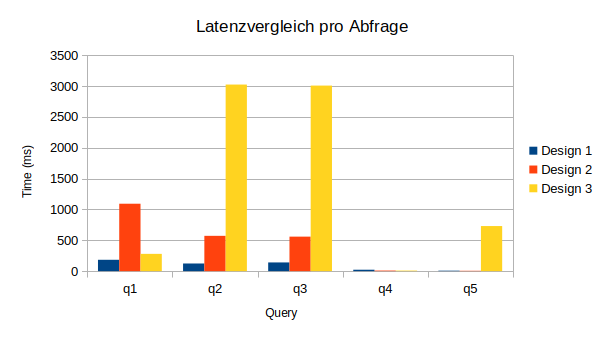

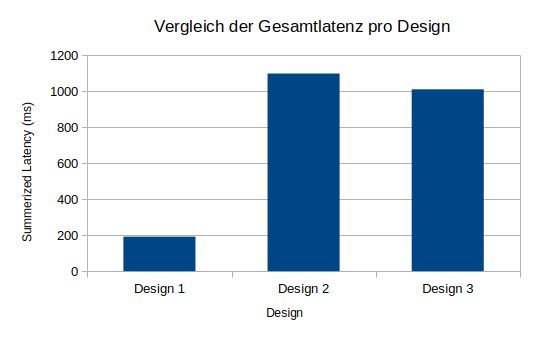

In [ ]:
# Ihre Lösung

Passen Sie die folgende Tabelle ggf. entsprechend an. Folgen Sie dabei der Anleitung in Aufgabe 1.1.

Query  | **Design 1** | **Design 2** | **Design 3**
:-----:|:------------:|:------------:|:--------:
**Q1** |              |              |
...    | ...          | ...          | ...

# Schema-Verbesserung
In diesem Abschnitt werden mögliche Verbesserungen zu den im ersten Teil dieses Blattes besprochenen Entwürfen festgehalten.

## Auch gute Ideen brauchen ein Update
Hatten Sie nach der Arbeit mit dem ausgewählten Design weiterhin das Gefühl, die richtige Wahl getroffen zu haben? Welche Änderungen würden Ihrer Meinung nach zur Verbesserung des Entwurfs beitragen?

Zum Abschluss schließen wir die Verbindung zur `refill_mundraub`-Datenbank und stoppen den Docker-Container. Bitte führen Sie die nächste Zelle aus, um die Verbindung zu beenden.

In [ ]:
mongo_client.close()

Zum Stoppen des MongoDB-Containers führen Sie den folgenden Befehl aus. Aufgrund des `--rm` Flags wird der Container danach automatisch entfernt

In [ ]:
%%bash

# stop the mongodb docker container
if [ -z $(sudo docker ps --filter "name=mongo_container_1" -q) ]; then
    printf "\nthe container does not exist\n";
else 
    printf "\nstopping the container ...\n";
    sudo docker stop mongo_container_1
fi

# Notizen
Persönliche Notizen ;)